<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Project 1: Standardized Test Analysis

### Contents:
- [Coding Challenges](#Coding-Challenges)
- [Data Import](#Data-Import)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)


### Coding Challenges

1. Manually calculate mean:

    Write a function that takes in values and returns the mean of the values. Create a list of numbers that you test on your function to check to make sure your function works!
    
    *Note*: Do not use any mean methods built-in to any Python libraries to do this! This should be done without importing any additional libraries.

In [1]:
# Code:
def calculate_mean(numbers):
    total = sum(numbers)
    mean = total / len(numbers)
    return mean

2. Manually calculate standard deviation:

    The formula for standard deviation is below:

    $$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n(x_i - \mu)^2}$$

    Where $x_i$ represents each value in the dataset, $\mu$ represents the mean of all values in the dataset and $n$ represents the number of values in the dataset.

    Write a function that takes in values and returns the standard deviation of the values using the formula above. Hint: use the function you wrote above to calculate the mean! Use the list of numbers you created above to test on your function.
    
    *Note*: Do not use any standard deviation methods built-in to any Python libraries to do this! This should be done without importing any additional libraries.

In [2]:
# Code:
def calculate_standard_deviation(numbers):
    mean = sum(numbers) / len(numbers)
    squared_diffs = [(x - mean) ** 2 for x in numbers]
    variance = sum(squared_diffs) / len(numbers)
    standard_deviation = variance ** 0.5
    return standard_deviation

3. Data cleaning function:
    
    Write a function that takes in a string that is a number and a percent symbol (ex. '50%', '30.5%', etc.) and converts this to a float that is the decimal approximation of the percent. For example, inputting '50%' in your function should return 0.5, '30.5%' should return 0.305, etc. Make sure to test your function to make sure it works!

You will use these functions later on in the project!

--- 
# Part 2

Part 2 requires knowledge of Pandas, EDA, data cleaning, and data visualization.

---

In [3]:
# Imports:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('./data/sat_snap_2018_2019.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 11 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   state                                                      51 non-null     object 
 1   participation_rate_2018                                    51 non-null     float64
 2   total_score_2018                                           51 non-null     int64  
 3   participation_rate_2019                                    51 non-null     float64
 4   total_score_2019                                           51 non-null     int64  
 5   total_number_of_snap_households_in_thousands_2018          51 non-null     int64  
 6   number_of_snap_households_with_children_in_thousands_2018  51 non-null     int64  
 7   percentage_of_snap_households_with_children_2018           51 non-null     float64
 8   total_number

In [6]:
df.head()

,state,participation_rate_2018,total_score_2018,participation_rate_2019,total_score_2019,total_number_of_snap_households_in_thousands_2018,number_of_snap_households_with_children_in_thousands_2018,percentage_of_snap_households_with_children_2018,total_number_of_snap_households_in_thousands_2019,number_of_snap_households_with_children_in_thousands_2019,percentage_of_snap_households_with_children_2019
0,Alabama,0.06,1166,0.07,1143,354,168,0.476,354,168,0.476
1,Alaska,0.43,1106,0.41,1097,39,16,0.413,39,16,0.413
2,Arizona,0.29,1149,0.31,1134,377,175,0.463,377,175,0.463
3,Arkansas,0.05,1169,0.06,1141,161,78,0.483,161,78,0.483
4,California,0.60,1076,0.63,1065,1911,940,0.492,1911,940,0.492


**To-Do:** *Edit the table below to create your own data dictionary for the datasets you chose.*

|Feature|Type|Dataset|Description|
|---|---|---|---|
|column name|int/float/object|ACT/SAT|This is an example| 


## Exploratory Data Analysis

Complete the following steps to explore your data. You are welcome to do more EDA than the steps outlined here as you feel necessary:
1. Summary Statistics.
2. Use a **dictionary comprehension** to apply the standard deviation function you create in part 1 to each numeric column in the dataframe.  **No loops**.
    - Assign the output to variable `sd` as a dictionary where: 
        - Each column name is now a key 
        - That standard deviation of the column is the value 
        - *Example Output :* `{'ACT_Math': 120, 'ACT_Reading': 120, ...}`
3. Investigate trends in the data.
    - Using sorting and/or masking (along with the `.head()` method to avoid printing our entire dataframe), consider questions relevant to your problem statement. Some examples are provided below (but feel free to change these questions for your specific problem):
        - Which states have the highest and lowest participation rates for the 2017, 2019, or 2019 SAT and ACT?
        - Which states have the highest and lowest mean total/composite scores for the 2017, 2019, or 2019 SAT and ACT?
        - Do any states with 100% participation on a given test have a rate change year-to-year?
        - Do any states show have >50% participation on *both* tests each year?
        - Which colleges have the highest median SAT and ACT scores for admittance?
        - Which California school districts have the highest and lowest mean test scores?
    - **You should comment on your findings at each step in a markdown cell below your code block**. Make sure you include at least one example of sorting your dataframe by a column, and one example of using boolean filtering (i.e., masking) to select a subset of the dataframe.

In [7]:
sd = {column: calculate_standard_deviation(df[column].values) for column in df.select_dtypes(include=['int64', 'float64']).columns}
sd

{'participation_rate_2018': 0.3694661922353942,
 'total_score_2018': 93.22742384464433,
 'participation_rate_2019': 0.3836584048685726,
 'total_score_2019': 96.24027185617864,
 'total_number_of_snap_households_in_thousands_2018': 435.0237581177312,
 'number_of_snap_households_with_children_in_thousands_2018': 193.44280399124145,
 'percentage_of_snap_households_with_children_2018': 0.06468271124040972,
 'total_number_of_snap_households_in_thousands_2019': 435.0237581177312,
 'number_of_snap_households_with_children_in_thousands_2019': 193.44280399124145,
 'percentage_of_snap_households_with_children_2019': 0.06468271124040972}

### 1. Which states have the highest and lowest participation rates for the SAT in 2017, 2018, or 2019?

In [8]:
# States with highest and lowest participation rates for 2018 SAT
highest_participation_2018 = df.sort_values('participation_rate_2018', ascending=False)['state'].head()
lowest_participation_2018 = df.sort_values('participation_rate_2018')['state'].head()
print(f'Highest Participation Rates in 2018: {list(highest_participation_2018)}')
print(f'Lowest Participation Rates in 2018: {list(lowest_participation_2018)}')

#states with highest and lowest participation rates for 2019 SAT
highest_participation_2019 = df.sort_values('participation_rate_2019', ascending=False)['state'].head()
lowest_participation_2019 = df.sort_values('participation_rate_2019')['state'].head()
print(f'Highest Participation Rates in 2019: {list(highest_participation_2019)}')
print(f'Lowest Participation Rates in 2019: {list(lowest_participation_2019)}')


Highest Participation Rates in 2018: ['Colorado', 'Connecticut', 'Delaware', 'Michigan', 'Idaho']
Lowest Participation Rates in 2018: ['North Dakota', 'Wyoming', 'South Dakota', 'Nebraska', 'Wisconsin']
Highest Participation Rates in 2019: ['Rhode Island', 'Illinois', 'Michigan', 'Colorado', 'Connecticut']
Lowest Participation Rates in 2019: ['North Dakota', 'Wyoming', 'South Dakota', 'Nebraska', 'Wisconsin']


### 2. Which states have the highest and lowest mean total scores for the SAT in 2017, 2018, or 2019?

In [9]:
# States with highest and lowest total scores for the 2018 SAT
highest_score_2018 = df.sort_values('total_score_2018', ascending=False)['state'].head()
lowest_score_2018 = df.sort_values('total_score_2018')['state'].head()
print(f'Highest Scores in 2018: {list(highest_score_2018)}')
print(f'Lowest Scores in 2018: {list(lowest_score_2018)}')

# States with highest and lowest total scores for the 2019 SAT
highest_score_2019 = df.sort_values('total_score_2019', ascending=False)['state'].head()
lowest_score_2019 = df.sort_values('total_score_2019')['state'].head()
print(f'Highest Scores in 2019: {list(highest_score_2019)}')
print(f'Lowest Scores in 2019: {list(lowest_score_2019)}')

Highest Scores in 2018: ['Minnesota', 'Wisconsin', 'North Dakota', 'Iowa', 'Kansas']
Lowest Scores in 2018: ['District of Columbia', 'Delaware', 'West Virginia', 'Idaho', 'Utah']
Highest Scores in 2019: ['Minnesota', 'Wisconsin', 'South Dakota', 'North Dakota', 'Nebraska']
Lowest Scores in 2019: ['West Virginia', 'Oklahoma', 'District of Columbia', 'Delaware', 'Idaho']


### 3. Do any states with 100% participation on the SAT have a rate change year-to-year?

In [10]:
# Change in participation rate from 2018 to 2019
df['participation_rate_change'] = df['participation_rate_2019'] - df['participation_rate_2018']
states_with_rate_change = df[df['participation_rate_change'] != 0]['state']

print(f'States with change in participation rate from 2018 to 2019: {list(states_with_rate_change)}')

States with change in participation rate from 2018 to 2019: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Illinois', 'Indiana', 'Louisiana', 'Maryland', 'Massachusetts', 'Montana', 'Nevada', 'New Hampshire', 'New Mexico', 'North Carolina', 'Oklahoma', 'Ohio', 'Oregon', 'Rhode Island', 'South Carolina', 'Tennessee', 'Texas', 'Vermont', 'Washington', 'West Virginia']


### 4. Do any states show >50% participation on the SAT each year?

In [11]:
high_participation_all_years = df[(df['participation_rate_2018'] > 0.5) & (df['participation_rate_2019'] > 0.5)]

print('States with >50% participation on the SAT in each year:')
for index, row in high_participation_all_years.iterrows():
    state = row['state']
    participation_2018 = row['participation_rate_2018']
    participation_2019 = row['participation_rate_2019']
    print(f'State: {state}, 2018 Participation: {participation_2018:.2%}, 2019 Participation: {participation_2019:.2%}')

States with >50% participation on the SAT in each year:
State: California, 2018 Participation: 60.00%, 2019 Participation: 63.00%
State: Colorado, 2018 Participation: 100.00%, 2019 Participation: 100.00%
State: Connecticut, 2018 Participation: 100.00%, 2019 Participation: 100.00%
State: Delaware, 2018 Participation: 100.00%, 2019 Participation: 100.00%
State: District of Columbia, 2018 Participation: 92.00%, 2019 Participation: 94.00%
State: Florida, 2018 Participation: 56.00%, 2019 Participation: 100.00%
State: Georgia, 2018 Participation: 70.00%, 2019 Participation: 71.00%
State: Hawaii, 2018 Participation: 56.00%, 2019 Participation: 54.00%
State: Idaho, 2018 Participation: 100.00%, 2019 Participation: 100.00%
State: Illinois, 2018 Participation: 99.00%, 2019 Participation: 100.00%
State: Indiana, 2018 Participation: 63.00%, 2019 Participation: 66.00%
State: Maine, 2018 Participation: 99.00%, 2019 Participation: 99.00%
State: Maryland, 2018 Participation: 76.00%, 2019 Participation:

In [12]:
snap_sat_corr = df['percentage_of_snap_households_with_children_2019'].corr(df['total_score_2019'])
print(f'Correlation between SAT scores and SNAP participation: {snap_sat_corr}')

Correlation between SAT scores and SNAP participation: 0.24164228720779807


* not very much correlation between these two

### 5. what're the highest total number of SNAP households in 2019?

In [13]:
# Top 10 states with the highest total number of SNAP households in 2019
top_snap_states = df.sort_values('total_number_of_snap_households_in_thousands_2019', ascending=False).head(10)
print(top_snap_states[['state', 'total_number_of_snap_households_in_thousands_2019']])


             state  total_number_of_snap_households_in_thousands_2019
4       California                                               1911
9          Florida                                               1632
43           Texas                                               1595
32        New York                                               1520
38    Pennsylvania                                                946
13        Illinois                                                904
10         Georgia                                                699
36            Ohio                                                698
22        Michigan                                                672
33  North Carolina                                                634


### 6. Whatre the highest percentage of SNAP households with children in 2019

In [14]:
# Top 10 states with the highest percentage of SNAP households with children in 2019
top_snap_children_states = df.sort_values('percentage_of_snap_households_with_children_2019', ascending=False).head(10)
print(top_snap_children_states[['state', 'percentage_of_snap_households_with_children_2019']])


             state  percentage_of_snap_households_with_children_2019
43           Texas                                             0.534
44            Utah                                             0.513
4       California                                             0.492
50         Wyoming                                             0.487
3         Arkansas                                             0.483
40  South Carolina                                             0.483
24     Mississippi                                             0.477
0          Alabama                                             0.476
12           Idaho                                             0.473
10         Georgia                                             0.468


## Visualize the Data

There's not a magic bullet recommendation for the right number of plots to understand a given dataset, but visualizing your data is *always* a good idea. Not only does it allow you to quickly convey your findings (even if you have a non-technical audience), it will often reveal trends in your data that escaped you when you were looking only at numbers. It is important to not only create visualizations, but to **interpret your visualizations** as well.

**Every plot should**:
- Have a title
- Have axis labels
- Have appropriate tick labels
- Text is legible in a plot
- Plots demonstrate meaningful and valid relationships
- Have an interpretation to aid understanding

Here is an example of what your plots should look like following the above guidelines. Note that while the content of this example is unrelated, the principles of visualization hold:

![](https://snag.gy/hCBR1U.jpg)
*Interpretation: The above image shows that as we increase our spending on advertising, our sales numbers also tend to increase. There is a positive correlation between advertising spending and sales.*

---

Here are some prompts to get you started with visualizations. Feel free to add additional visualizations as you see fit:
1. Use Seaborn's heatmap with pandas `.corr()` to visualize correlations between all numeric features.
    - Heatmaps are generally not appropriate for presentations, and should often be excluded from reports as they can be visually overwhelming. **However**, they can be extremely useful in identify relationships of potential interest (as well as identifying potential collinearity before modeling).
    - Please take time to format your output, adding a title. Look through some of the additional arguments and options. (Axis labels aren't really necessary, as long as the title is informative).
2. Visualize distributions using histograms. If you have a lot, consider writing a custom function and use subplots.
    - *OPTIONAL*: Summarize the underlying distributions of your features (in words & statistics)
         - Be thorough in your verbal description of these distributions.
         - Be sure to back up these summaries with statistics.
         - We generally assume that data we sample from a population will be normally distributed. Do we observe this trend? Explain your answers for each distribution and how you think this will affect estimates made from these data.
3. Plot and interpret boxplots. 
    - Boxplots demonstrate central tendency and spread in variables. In a certain sense, these are somewhat redundant with histograms, but you may be better able to identify clear outliers or differences in IQR, etc.
    - Multiple values can be plotted to a single boxplot as long as they are of the same relative scale (meaning they have similar min/max values).
    - Each boxplot should:
        - Only include variables of a similar scale
        - Have clear labels for each variable
        - Have appropriate titles and labels
4. Plot and interpret scatter plots to view relationships between features. Feel free to write a custom function, and subplot if you'd like. Functions save both time and space.
    - Your plots should have:
        - Two clearly labeled axes
        - A proper title
        - Colors and symbols that are clear and unmistakable
5. Additional plots of your choosing.
    - Are there any additional trends or relationships you haven't explored? Was there something interesting you saw that you'd like to dive further into? It's likely that there are a few more plots you might want to generate to support your narrative and recommendations that you are building toward. **As always, make sure you're interpreting your plots as you go**.

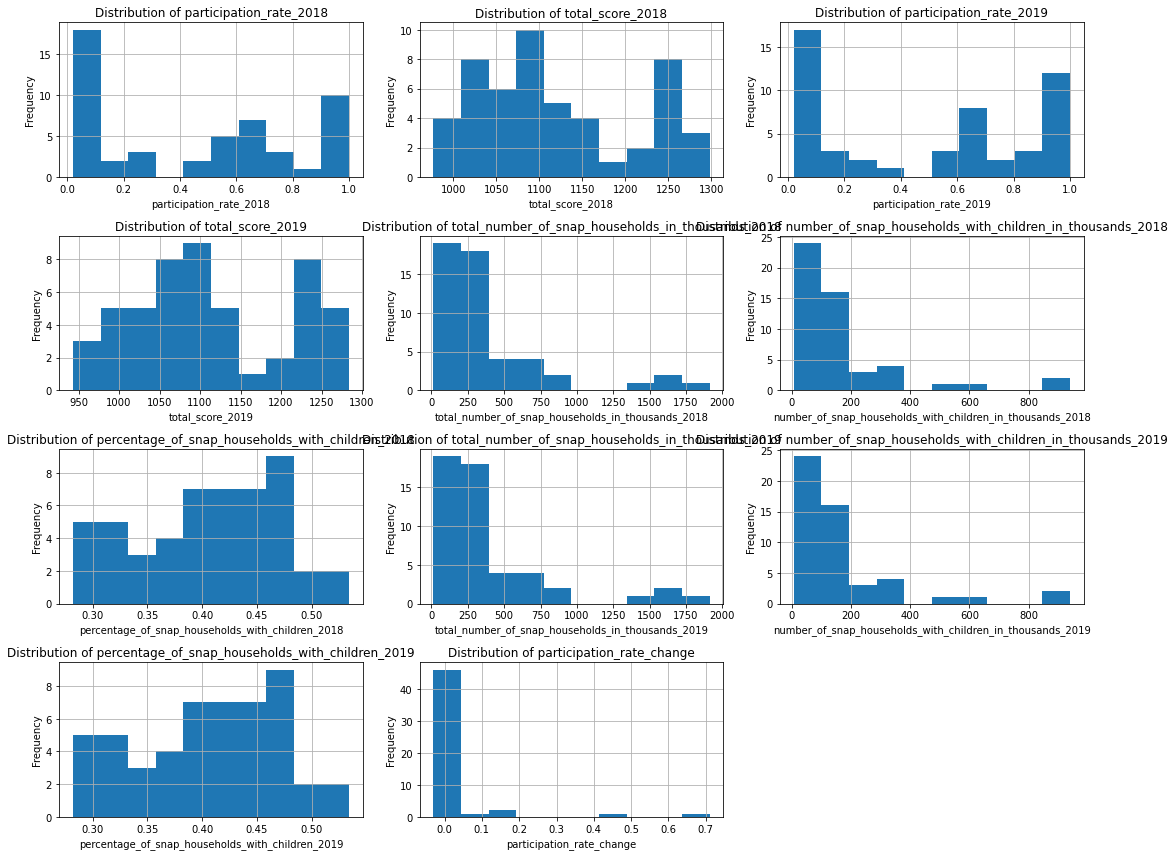

In [16]:
# Make some Histograms 
def generate_histograms(df):
    plt.figure(figsize=(15, 12))
    for i, column in enumerate(df.select_dtypes(['int64', 'float64']).columns):
        plt.subplot(4, 3, i+1)
        df[column].hist()
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
    plt.tight_layout()
    
generate_histograms(df)


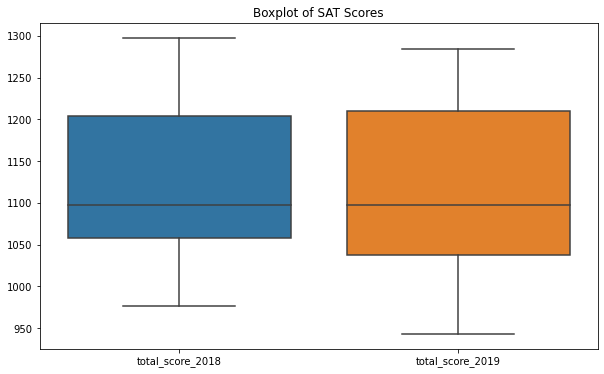

In [17]:
# Boxplot for SAT scores
sat_scores = ['total_score_2018', 'total_score_2019']
plt.figure(figsize=(10,6))
sns.boxplot(data=df[sat_scores])
plt.title('Boxplot of SAT Scores')
plt.show()


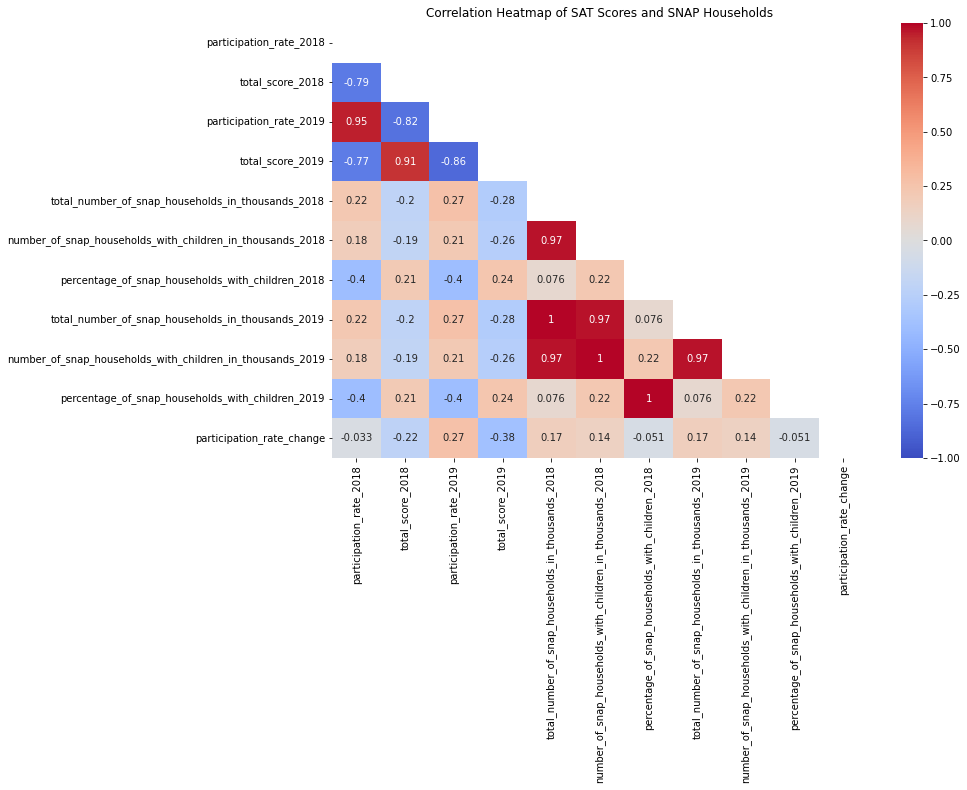

In [19]:
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))  # Mask for the upper triangle
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=mask)  # Apply mask
plt.title('Correlation Heatmap of SAT Scores and SNAP Households')
plt.show()

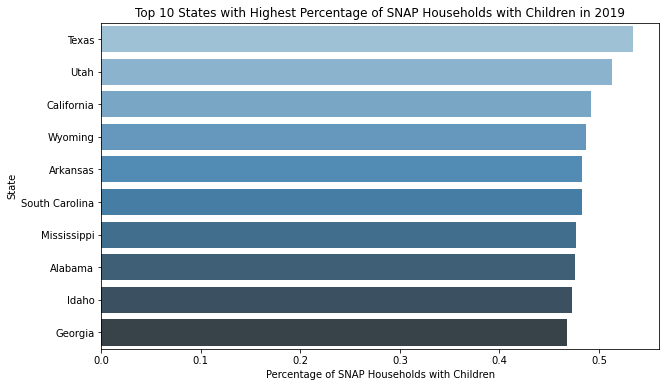

In [167]:
# Plotting top 10 states with the highest percentage of SNAP households with children
plt.figure(figsize=(10, 6))
sns.barplot(x='percentage_of_snap_households_with_children_2019', y='state', data=top_snap_children_states, palette="Blues_d")
plt.title('Top 10 States with Highest Percentage of SNAP Households with Children in 2019')
plt.xlabel('Percentage of SNAP Households with Children')
plt.ylabel('State')
plt.show()

### 5. How does the percentage of participating SNAP households with children vary across states in fiscal years 2018 and 2019?

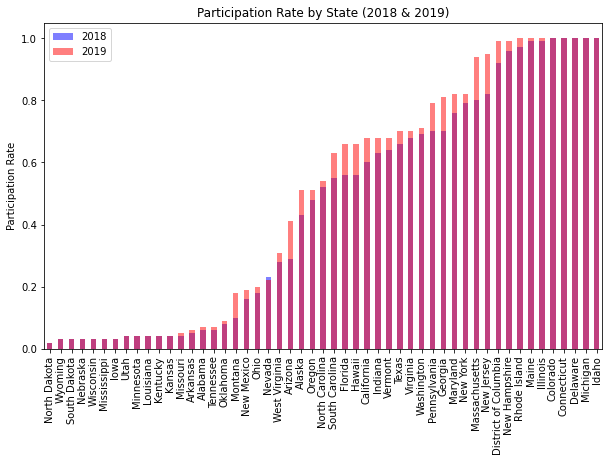

In [21]:
plt.figure(figsize=(10, 6))

# First plot for 2018
df.sort_values('participation_rate_2018')['participation_rate_2018'].plot(kind='bar', color='b', alpha=0.5)

# Second plot for 2019, overlaid
df.sort_values('participation_rate_2019')['participation_rate_2019'].plot(kind='bar', color='r', alpha=0.5)

plt.xticks(range(df.shape[0]), df.sort_values('participation_rate_2018')['state'].values, rotation=90)
plt.title('Participation Rate by State (2018 & 2019)')
plt.ylabel('Participation Rate')

# Adding legend
plt.legend(["2018", "2019"], loc='upper left')

plt.show()


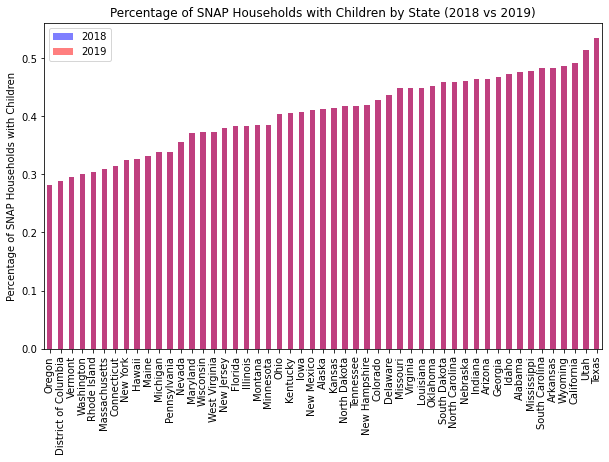

In [26]:
df_sorted = df.sort_values('percentage_of_snap_households_with_children_2018')

plt.figure(figsize=(10, 6))
df_sorted['percentage_of_snap_households_with_children_2018'].plot(kind='bar', color='blue', alpha=0.5)
df_sorted['percentage_of_snap_households_with_children_2019'].plot(kind='bar', color='red', alpha=0.5)
plt.xticks(range(df.shape[0]), df_sorted['state'].values, rotation=90)
plt.title('Percentage of SNAP Households with Children by State (2018 vs 2019)')
plt.ylabel('Percentage of SNAP Households with Children')
plt.legend(['2018', '2019'])
plt.show()


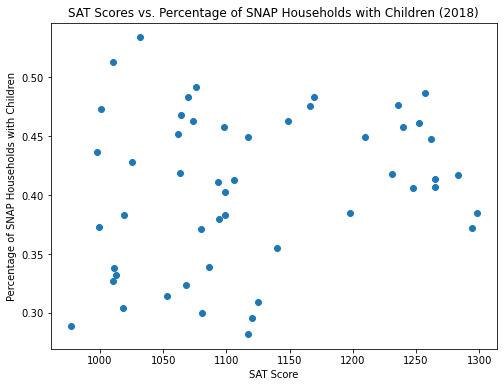

Correlation coefficient for 2018: 0.21047352773698608


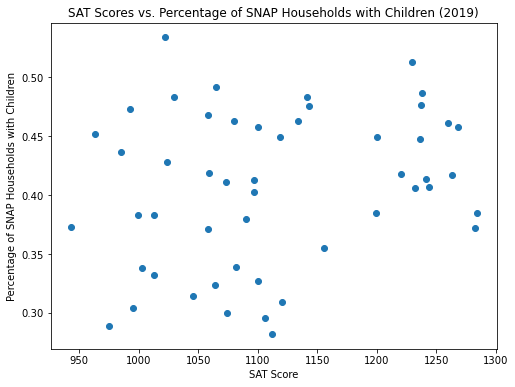

Correlation coefficient for 2019: 0.24164228720779796


In [23]:
# 2018
plt.figure(figsize=(8, 6))
plt.scatter(df['total_score_2018'], df['percentage_of_snap_households_with_children_2018'])
plt.title('SAT Scores vs. Percentage of SNAP Households with Children (2018)')
plt.xlabel('SAT Score')
plt.ylabel('Percentage of SNAP Households with Children')
plt.show()

correlation_2018 = df[['total_score_2018', 'percentage_of_snap_households_with_children_2018']].corr().iloc[0, 1]
print(f"Correlation coefficient for 2018: {correlation_2018}")

# 2019
plt.figure(figsize=(8, 6))
plt.scatter(df['total_score_2019'], df['percentage_of_snap_households_with_children_2019'])
plt.title('SAT Scores vs. Percentage of SNAP Households with Children (2019)')
plt.xlabel('SAT Score')
plt.ylabel('Percentage of SNAP Households with Children')
plt.show()

correlation_2019 = df[['total_score_2019', 'percentage_of_snap_households_with_children_2019']].corr().iloc[0, 1]
print(f"Correlation coefficient for 2019: {correlation_2019}")


### 2. Is there any correlation between the percentage of participating SNAP households with children and SAT scores by state in fiscal years 2018 and 2019?

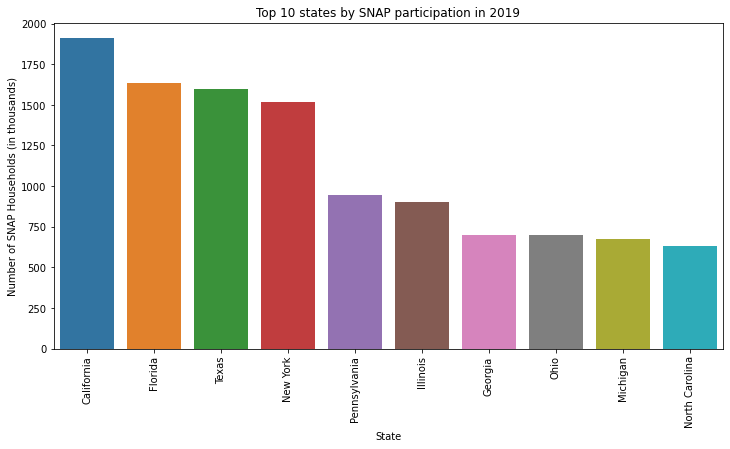

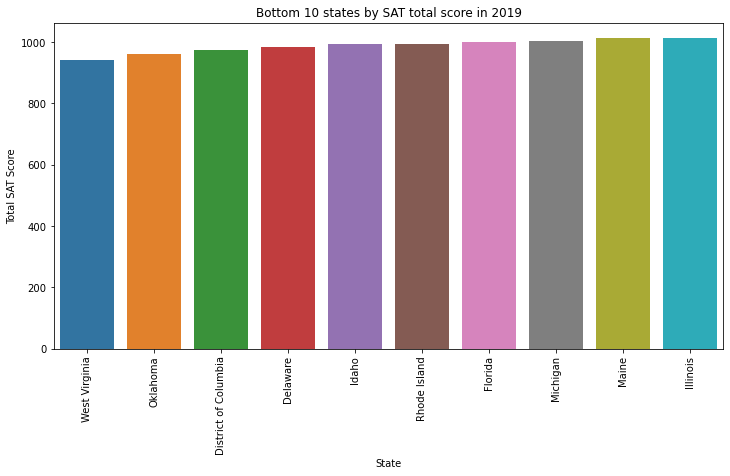

In [25]:
# Get the top 10 states by participation in SNAP in 2019
top_snap_states = df.sort_values('total_number_of_snap_households_in_thousands_2019', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='state', y='total_number_of_snap_households_in_thousands_2019', data=top_snap_states)
plt.title('Top 10 states by SNAP participation in 2019')
plt.xlabel('State')
plt.ylabel('Number of SNAP Households (in thousands)')
plt.xticks(rotation=90)
plt.show()

# Get the bottom 10 states by SAT score in 2019
bottom_sat_states = df.sort_values('total_score_2019', ascending=True).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='state', y='total_score_2019', data=bottom_sat_states)
plt.title('Bottom 10 states by SAT total score in 2019')
plt.xlabel('State')
plt.ylabel('Total SAT Score')
plt.xticks(rotation=90)
plt.show()


## Conclusions and Recommendations

Based on your exploration of the data, what are you key takeaways and recommendations? Make sure to answer your question of interest or address your problem statement here.

There aren't any noticeable relationships between SNAP participation and SAT scores for the years of 2018-2019. Although it's likely because the data used was limited in its ability to establish a clear connection between these two variables. The data examined only includes overall state-level SNAP participation and SAT scores, and these are aggregate measures that can encompass a wide range of underlying factors. Both SNAP participation and SAT scores can be influenced by a multitude of socio-economic and educational factors that are not directly measured in the dataset, such as income inequality, quality of education, state educational funding, etc.

To make a more definitive conclusion, it'd be beneficial to have a more granular dataset that includes information at a more local level (such as county or school district), and additional variables that can potentially influence both SNAP participation and SAT scores. For instance, socio-economic indicators like median household income, unemployment rate, education level, and percentage of students receiving free or reduced-price lunch at school could provide more context and allow for a more in-depth analysis.

Don't forget to create your README!

**To-Do:** *If you combine your problem statement, data dictionary, brief summary of your analysis, and conclusions/recommendations, you have an amazing README.md file that quickly aligns your audience to the contents of your project.* Don't forget to cite your data sources!